In [75]:
import numpy as np
import pandas as pd
import json
import io
import math
from abc import abstractmethod
from collections import deque
from typing import List, Tuple, Dict
from datamodel import Listing, Observation, Order, OrderDepth, ProsperityEncoder, Symbol, Trade, TradingState
from enum import IntEnum
from statistics import NormalDist
from typing import Any, TypeAlias
from collections import defaultdict
import matplotlib.pyplot as plt
import re
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
# import ace_tools as tools

JSON: TypeAlias = dict[str, "JSON"] | list["JSON"] | str | int | float | bool | None

product = 'SQUID_INK'

In [76]:
def _process_data_(file):
    with open(file, 'r') as file:
        log_content = file.read()
    sections = log_content.split('Sandbox logs:')[1].split('Activities log:')
    my_data = sections[0].strip()
    sandbox_log =  sections[0].strip()
    activities_log = sections[1].split('Trade History:')[0]
    # sandbox_log_list = [json.loads(line) for line in sandbox_log.split('\n')]
    trade_history =  json.loads(sections[1].split('Trade History:')[1])
    # sandbox_log_df = pd.DataFrame(sandbox_log_list)
    market_data_df = pd.read_csv(io.StringIO(activities_log), sep=";", header=0)
    trade_history_df = pd.json_normalize(trade_history)
    return market_data_df, trade_history_df, my_data

market_data, trade_history, my_data = _process_data_('test.log')

In [77]:
market_data.head(20)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,SQUID_INK,1834,23,NaN,NaN,NaN,NaN,1838,23,NaN,NaN,NaN,NaN,1836.0,0.000000
1,1,0,RAINFOREST_RESIN,9998,9,9995.0,23.0,NaN,NaN,10005,23,NaN,NaN,NaN,NaN,10001.5,0.000000
2,1,0,KELP,2032,23,NaN,NaN,NaN,NaN,2035,23,NaN,NaN,NaN,NaN,2033.5,0.000000
3,1,100,KELP,2034,1,2033.0,2.0,2032.0,22.0,2035,22,NaN,NaN,NaN,NaN,2034.5,-1.387329
4,1,100,SQUID_INK,1837,1,1836.0,2.0,1835.0,22.0,1839,22,NaN,NaN,NaN,NaN,1838.0,-2.998535
5,1,100,RAINFOREST_RESIN,10002,1,10000.0,2.0,9998.0,4.0,10004,1,10005.0,21.0,NaN,NaN,10003.0,-2.000000
6,1,200,RAINFOREST_RESIN,9996,1,9995.0,21.0,NaN,NaN,10004,1,10005.0,21.0,NaN,NaN,10000.0,-6.000000
7,1,200,KELP,2032,22,NaN,NaN,NaN,NaN,2035,22,NaN,NaN,NaN,NaN,2033.5,-3.000000
8,1,200,SQUID_INK,1832,22,NaN,NaN,NaN,NaN,1835,22,NaN,NaN,NaN,NaN,1833.5,-5.000000
9,1,300,KELP,2034,1,2032.0,26.0,NaN,NaN,2035,26,NaN,NaN,NaN,NaN,2034.5,-4.327515


In [78]:
market_orders = trade_history[(trade_history['buyer']!="SUBMISSION") & (trade_history['seller']!="SUBMISSION") & (trade_history['symbol']==product)]
buy_order = trade_history[(trade_history['buyer']=="SUBMISSION") & (trade_history['symbol']== product)]
sell_order = trade_history[(trade_history['seller']=="SUBMISSION") & (trade_history['symbol']==product)]
market = market_data[market_data['product']==product]

market_orders.loc[:, 'timestamp'] /= 100
buy_order.loc[:, 'timestamp'] /= 100
sell_order.loc[:, 'timestamp'] /= 100
market.loc[:, 'timestamp'] /= 100

In [79]:
trade_history[(trade_history['symbol'] == product)]

,timestamp,buyer,seller,symbol,currency,price,quantity
2,0,,SUBMISSION,SQUID_INK,SEASHELLS,1834,1
5,100,SUBMISSION,,SQUID_INK,SEASHELLS,1839,1
10,200,,SUBMISSION,SQUID_INK,SEASHELLS,1832,1
13,200,,,SQUID_INK,SEASHELLS,1835,1
16,300,SUBMISSION,,SQUID_INK,SEASHELLS,1837,1
...,...,...,...,...,...,...,...
3768,99700,SUBMISSION,,SQUID_INK,SEASHELLS,1817,1
3771,99700,,,SQUID_INK,SEASHELLS,1813,2
3774,99800,,SUBMISSION,SQUID_INK,SEASHELLS,1814,1
3777,99900,SUBMISSION,,SQUID_INK,SEASHELLS,1819,1


In [80]:
df = trade_history[(trade_history['symbol'] == product)].reset_index(drop=True)
df = df[(df['buyer']=='SUBMISSION')|(df['seller']=='SUBMISSION')]
df = df.reset_index(drop=True)

market = market_data[market_data['product'] == product].reset_index(drop=True)
# df = df.drop(index=769).reset_index(drop=True)
df['pnl'] = market['profit_and_loss']
df['pnl'] =  df['pnl'] - df['pnl'].shift(1)

In [81]:
for i in range(len(df.index)):
    if df.loc[i,'buyer'] == 'SUBMISSION':
        df.loc[i,'ind'] = 1
    else:
        df.loc[i,'ind'] = -1
df['p'] = df['price'] + df['pnl']*df['ind']

market = market_data[market_data['product'] == product ].reset_index(drop=True)

In [82]:
dff = market
def weighted_avg_price(prices, volumes):
    prices = np.array(prices, dtype=np.float64)
    volumes = np.array(volumes, dtype=np.float64)
    mask = ~np.isnan(prices) & ~np.isnan(volumes)
    
    if np.sum(volumes[mask]) == 0:
        return np.nan
    
    return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

# 假设你的 DataFrame 是 df
dff['weighted_bid'] = dff.apply(lambda row: weighted_avg_price(
    [row['bid_price_1'], row['bid_price_2'], row['bid_price_3']],
    [row['bid_volume_1'], row['bid_volume_2'], row['bid_volume_3']]
), axis=1)

dff['weighted_ask'] = dff.apply(lambda row: weighted_avg_price(
    [row['ask_price_1'], row['ask_price_2'], row['ask_price_3']],
    [row['ask_volume_1'], row['ask_volume_2'], row['ask_volume_3']]
), axis=1)

# 最终的加权中间价（加权 bid + 加权 ask）/ 2
df['weighted_mid'] = (dff['weighted_bid'] + dff['weighted_ask']) / 2

In [83]:
def full_book_weighted_price(row):
    prices = [
        row.get('bid_price_1'), row.get('bid_price_2'), row.get('bid_price_3'),
        row.get('ask_price_1'), row.get('ask_price_2'), row.get('ask_price_3')
    ]
    volumes = [
        row.get('bid_volume_1'), row.get('bid_volume_2'), row.get('bid_volume_3'),
        row.get('ask_volume_1'), row.get('ask_volume_2'), row.get('ask_volume_3')
    ]

    prices = np.array(prices, dtype=np.float64)
    volumes = np.array(volumes, dtype=np.float64)

    mask = ~np.isnan(prices) & ~np.isnan(volumes)
    if np.sum(volumes[mask]) == 0:
        return np.nan
    
    return np.sum(prices[mask] * volumes[mask]) / np.sum(volumes[mask])

df['book_weighted_price'] = dff.apply(full_book_weighted_price, axis=1)
df['t1'] = (market ['mid_price'] - df['book_weighted_price'])*2 + df['book_weighted_price']

In [84]:
df

,timestamp,buyer,seller,symbol,currency,price,quantity,pnl,ind,p,weighted_mid,book_weighted_price,t1
0,0,,SUBMISSION,SQUID_INK,SEASHELLS,1834,1,NaN,-1.0,NaN,1836.000000,1836.000000,1836.000000
1,100,SUBMISSION,,SQUID_INK,SEASHELLS,1839,1,-2.998535,1.0,1836.001465,1837.080000,1836.957447,1839.042553
2,200,,SUBMISSION,SQUID_INK,SEASHELLS,1832,1,-2.001465,-1.0,1834.001465,1833.500000,1833.500000,1833.500000
3,300,SUBMISSION,,SQUID_INK,SEASHELLS,1837,1,-3.368774,1.0,1833.631226,1835.537037,1835.509434,1837.490566
4,400,,SUBMISSION,SQUID_INK,SEASHELLS,1833,1,-1.631226,-1.0,1834.631226,1834.500000,1834.500000,1834.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,99500,SUBMISSION,,SQUID_INK,SEASHELLS,1818,1,-3.040161,1.0,1814.959839,1816.000000,1816.000000,1816.000000
996,99600,,SUBMISSION,SQUID_INK,SEASHELLS,1815,1,-1.959839,-1.0,1816.959839,1816.500000,1816.500000,1816.500000
997,99700,SUBMISSION,,SQUID_INK,SEASHELLS,1817,1,-0.077271,1.0,1816.922729,1815.000000,1815.000000,1815.000000
998,99800,,SUBMISSION,SQUID_INK,SEASHELLS,1814,1,-1.922729,-1.0,1815.922729,1815.500000,1815.500000,1815.500000


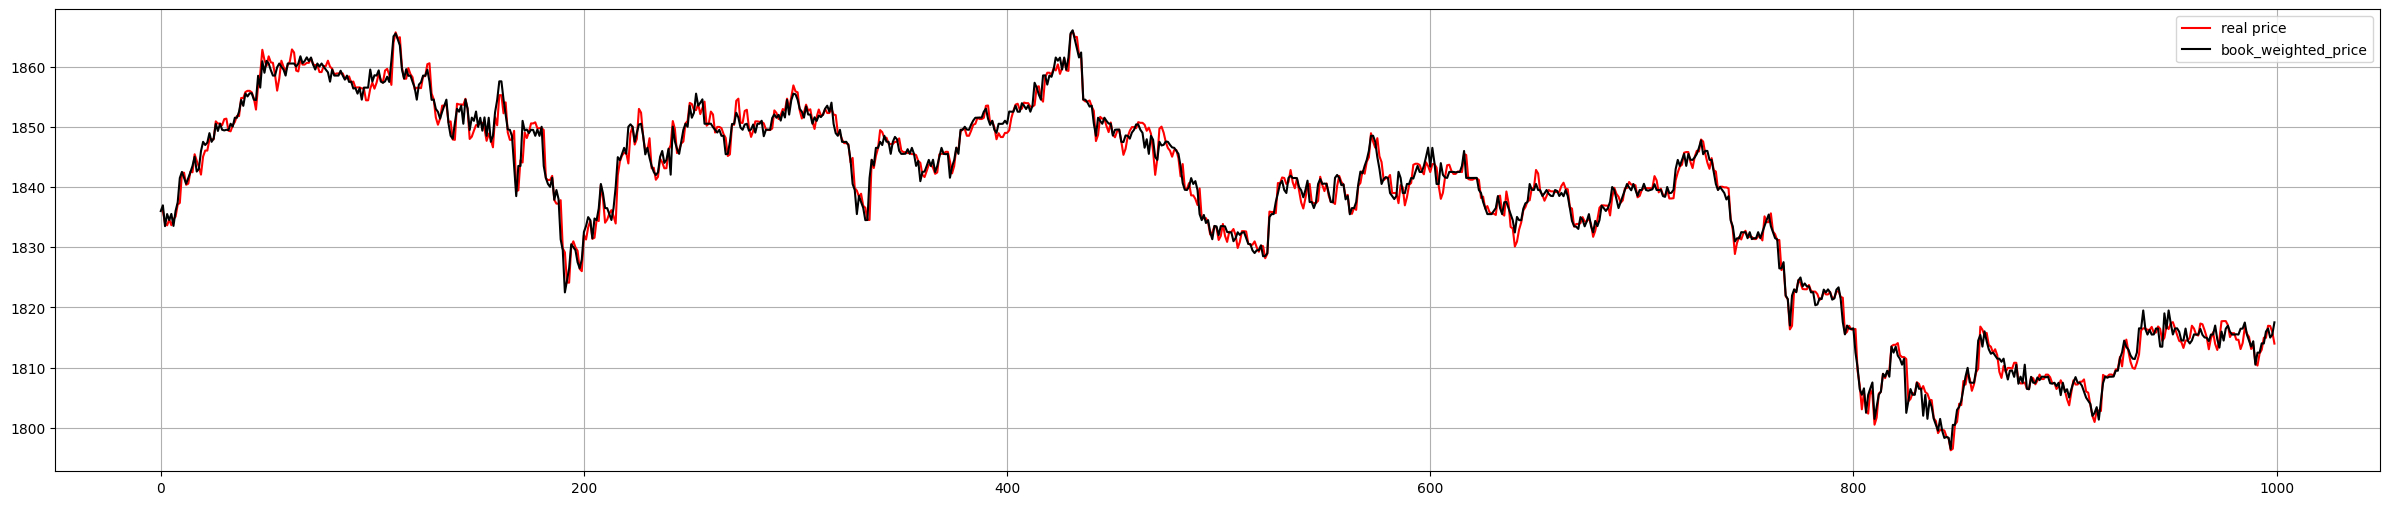

In [91]:
plt.figure(figsize=(30, 6))
plt.plot(df['p'], label='real price', color='red')
# plt.plot(market.mid_price, label='mid_price', color='blue')

# from scipy.signal import butter, filtfilt
# def butter_lowpass_filter(data, cutoff=0.1, fs=1.0, order=2):
#     b, a = butter(order, cutoff / (0.5 * fs), btype='low', analog=False)
#     y = filtfilt(b, a, data)
#     return y
# df['smoothed'] = butter_lowpass_filter(market.mid_price, cutoff=0.15, fs=1.0, order=5)

# plt.plot(market.mid_price.rolling(window=50).mean(), label='movmean', color='black')
# plt.plot(df['weighted_mid'], label='weighted_mid', color='blue')
plt.plot(df['book_weighted_price'], label='book_weighted_price', color='black')

# plt.plot(df['t1'], label='t1', color='green')
# plt.xlim(0, 500)

plt.legend()
plt.grid(True)

plt.show()